In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


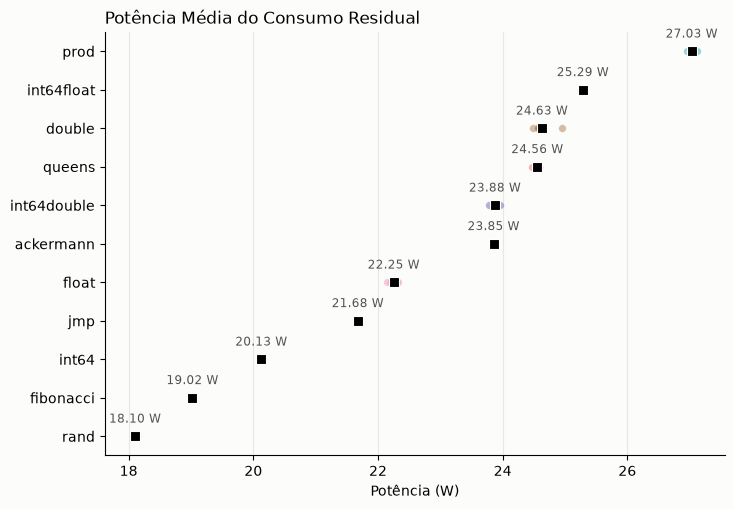

                                             Stress-ng      Média  Variância  \
0    stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.472399   0.008322   
2    stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.837423   0.016194   
4    stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.845729   0.006562   
6    stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.859919   0.002746   
8    stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.867004   0.005981   
10   stress-ng---cpu-6---cpu-method-ackermann--t-30...  23.860008   0.003420   
12   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.582953   0.011762   
14   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.575475   0.009194   
16   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.578151   0.005752   
18   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.568667   0.010323   
20   stress-ng---cpu-6---cpu-method-queens--t-30-20...  24.555918   0.014174   
22   stress-ng---cpu-6---cpu-method-fibo

In [32]:


cons = pd.read_csv("log_medicao_sequencial.csv",
                   names=["Stress-ng", "Média", "Variância"])
#ons = pd.read_csv("log_medicao_paralela.csv", names=["Stress-ng", "Média", "Variância"])

'''cons = cons.rename(columns={
    "stress-ng---cpu-6---cpu-method-queens--t-30-20260924_121141.csv": "Stress-ng",
    "24.4723993227684": "Info",
    "0.008322237037118985": "Média"
    })
'''

#print(cons.columns)

#cons = cons[~cons.astype(str).apply(lambda linha : linha.str.contains("n"),any(), axis=1)]

filtrado = cons.copy()

filtrado = filtrado.dropna(subset=["Variância"])

metodos = filtrado['Stress-ng'].str.findall(r'-method-([^-]+)')
filtrado['método'] = metodos.str[0]
filtrado['método2'] = metodos.str[1]
filtrado['par'] = metodos.apply(lambda m: tuple(sorted(m)))

filtrado['cpu'] = filtrado["Stress-ng"].str.split('--').str[1]

filtrado['tempo'] = filtrado['Stress-ng'].str.extract(r't-([^-]+)')
#tempo = filtrado["Stress-ng"].str.split('--').str[3]
#filtrado['tempo'] = tempo.str.split('-').str[1]

filtrado['data'] = filtrado['Stress-ng'].str.extract(r't-30-([^-]+)')
#data = filtrado["Stress-ng"].str.split('-').str[14]
#filtrado["data"] = data.str.split('_').str[0]

grupo = filtrado.groupby("método")["Média"]
#variância = grupo.var()


# ===== INÍCIO: cor por método + pontos individuais + média em destaque =====
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["savefig.facecolor"] = "#fcfcfb"
plt.rcParams["savefig.transparent"] = False

ordem = filtrado.groupby('método')['Média'].mean().sort_values().index
cores = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
         "#008300", "#4a3aa7", "#e34948", "#9c5a1f", "#6b7a00", "#0097a7"]
# slots 1-8 = paleta categórica validada da skill dataviz; 9-11 (terracota,
# oliva, ciano) são extras não validados -- usado porque o usuário pediu
# cor única por método mesmo sabendo do risco de CVD-safety (ver plano)

fig, ax = plt.subplots(figsize=(8, 5.5))
for i, metodo in enumerate(ordem):
    cor = cores[i]
    valores = filtrado.loc[filtrado['método'] == metodo, 'Média']
    ax.scatter(valores, [i] * len(valores), s=30, color=cor, alpha=0.4,
               edgecolors="white", linewidths=0.5, zorder=2)
    media = valores.mean()
    ax.scatter([media], [i], s=55, marker="s", color="black", edgecolors="white",
               linewidths=0.8, zorder=3)
    ax.text(media, i + 0.28, f"{media:.2f} W", ha="center", va="bottom",
            fontsize=8.5, color="#52514e")

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels(ordem, fontsize=10)
ax.set_xlabel("Potência (W)")
ax.set_title("Potência Média do Consumo Residual", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e8e7e2", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
fig.patch.set_facecolor("#fcfcfb")   # fundo sólido, sem transparência
ax.set_facecolor("#fcfcfb")
# ===== FIM: cor por método + pontos individuais + média em destaque =====



plt.show()
print(filtrado)
#filtrado.to_csv("paralela.csv")
#print(variância)

In [ ]:
#agrega as 10 execucoes de cada metodo em uma linha so.
#o desvio que importa e a dispersao ENTRE execucoes: ela ja contem o ruido
#intra-janela, porque cada media e ela mesma uma media de 10 amostras.
#desvio_intra_medio NAO e barra de erro - e o teste do criterio de 2 W do artigo
agregado = filtrado.groupby("método").agg(
    media_agregada=("Média", "mean"),
    desvio_entre_execucoes=("Média", "std"),
    erro_padrao=("Média", "sem"),
    desvio_intra_medio=("Variância", "mean"),
    execucoes=("Média", "size"),
)

agregado = agregado.sort_values("media_agregada").reset_index()

print(agregado.round(4).to_string(index=False))
z

     método  media_agregada  desvio_entre_execucoes  erro_padrao  desvio_intra_medio  execucoes
       rand          9.5762                  0.0284       0.0090              0.0133         10
  fibonacci          9.7256                  0.0644       0.0204              0.0193         10
      int64          9.9271                  0.0216       0.0068              0.0124         10
        jmp         10.1452                  0.0531       0.0168              0.0228         10
      float         10.3083                  0.0115       0.0036              0.0120         10
int64double         10.5559                  0.0563       0.0178              0.0171         10
  ackermann         10.5661                  0.0593       0.0188              0.0248         10
     double         10.6993                  0.0229       0.0072              0.0101         10
     queens         10.7065                  0.0297       0.0094              0.0114         10
 int64float         10.7262             

In [9]:
# o codigo abaixo analisa o erro dos metodos dispostos nos csvs
df = pd.read_csv("erro-por-par.csv")
display(df.sort_values(by="AE", ascending=False))

,cenario,par,AE
108,max,"('prod', 'rand')",0.195879
53,min,"('prod', 'rand')",0.172858
103,max,"('int64float', 'rand')",0.170865
79,max,"('fibonacci', 'prod')",0.166786
73,max,"('double', 'rand')",0.162289
...,...,...,...
0,min,"('ackermann', 'double')",0.009714
72,max,"('double', 'queens')",0.004641
17,min,"('double', 'queens')",0.004641
4,min,"('ackermann', 'int64double')",0.004553
